In [46]:
!pip install tensorflow pandas matplotlib scikit-learn
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import SGD
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [47]:
#Load the dataset

df = pd.read_csv('CombinedData.csv')
df = df.dropna(subset=['statement', 'status'])

In [48]:
df.head(20)

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety
5,5,"every break, you must be nervous, like somethi...",Anxiety
6,6,"I feel scared, anxious, what can I do? And may...",Anxiety
7,7,Have you ever felt nervous but didn't know why?,Anxiety
8,8,"I haven't slept well for 2 days, it's like I'm...",Anxiety
9,9,"I'm really worried, I want to cry.",Anxiety


In [49]:
def tokenizer(text):
    if pd.isna(text):
        return []
    text = str(text).lower().split()
    text = [word for word in text if word.strip()]
    return text

In [50]:
def Word2Vec(text):
    # Create a set of unique words in the text
    unique_words = set(text)
    
    # Create a dictionary to store the word vectors
    word_vectors = {}
    
    # Assign a random vector to each unique word
    for word in unique_words:
         # makes same word get same vector
        np.random.seed(abs(hash(word)) % (2**32)) 
        word_vectors[word] = np.random.rand(300)
    
    return word_vectors

In [51]:
def extract_features(text):
    tokens = tokenizer(text)
    if len(tokens) == 0:
        return np.zeros(300)

    word_vectors = Word2Vec(tokens)
    if len(word_vectors) == 0:
        return np.zeros(300)

    feature_vector = np.mean(list(word_vectors.values()), axis=0)
    return feature_vector

In [52]:
x_features = np.array(df['statement'].apply(extract_features).tolist())
y = df['status']

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


In [53]:
#train test split
x_train, x_test, y_train, y_test = train_test_split(
    x_features, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

x_train = x_train.reshape((x_train.shape[0], 1, x_train.shape[1]))
x_test = x_test.reshape((x_test.shape[0], 1, x_test.shape[1]))

In [54]:
class LSTM_Model:
    def build_model(self, input_size, hidden_size, output_size):
        model = Sequential()
        model.add(LSTM(units=hidden_size, input_shape=(1, input_size)))
        model.add(Dense(output_size, activation='softmax'))
        model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

    def __init__(self, input_size, hidden_size, output_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.model = self.build_model(input_size, hidden_size, output_size)

    def fit(self, x_train, y_train, epochs=10, batch_size=32, validation_split=0.2):
        return self.model.fit(
            x_train,
            y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split
        )

    def predict(self, x_test):
        return self.model.predict(x_test)

In [55]:
# Create LSTM model
input_size = 300
hidden_size = 128
output_size = len(np.unique(y_encoded))

lstm_model = LSTM_Model(input_size, hidden_size, output_size)

/Users/eniyamadden/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [56]:
# Train model
history = lstm_model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3257 - loss: 1.6210 - val_accuracy: 0.3910 - val_loss: 1.5978
Epoch 2/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 984us/step - accuracy: 0.4036 - loss: 1.5466 - val_accuracy: 0.4818 - val_loss: 1.4715
Epoch 3/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 992us/step - accuracy: 0.4525 - loss: 1.4762 - val_accuracy: 0.4859 - val_loss: 1.4255
Epoch 4/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 992us/step - accuracy: 0.4645 - loss: 1.4451 - val_accuracy: 0.4709 - val_loss: 1.4236
Epoch 5/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 978us/step - accuracy: 0.4746 - loss: 1.4165 - val_accuracy: 0.5007 - val_loss: 1.3796
Epoch 6/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 984us/step - accuracy: 0.4801 - loss: 1.3982 - val_accuracy: 0.4700 - val_loss: 1.3871
Epoch 7/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 981us/step - accuracy: 0.4852 - loss: 1.3793 - val_accuracy: 0.4934 - val_loss: 1.3483
Epoch 8/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 1s 980us/step - accuracy: 0.4888 - loss: 1.3623 - va

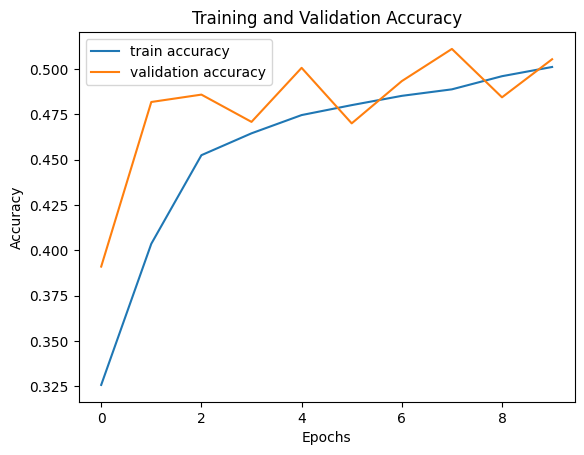

In [57]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()